# House Price Prediction Using Multiple Linear Regression

## Problem Statement

The real estate market is highly dynamic, and accurately predicting house prices is a critical task for buyers, sellers, and investors. Given a dataset containing various features of houses (e.g., area, bedrooms, bathrooms, and amenities like air conditioning or parking), the challenge is to develop a predictive model that can estimate house prices based on these attributes.

## Goal

The goal of this project is to build a Multiple Linear Regression (MLR) model to predict house prices using the provided dataset. The model should:

- Identify the most significant features influencing house prices.
- Provide accurate predictions on unseen data (test set).
- Be evaluated using appropriate metrics (e.g., R-squared, Mean Squared Error).

## Dataset Overview


**Housing.csv:**
- This dataset contains 545 rows and 13 columns, representing housing data with features such as price, area, bedrooms, bathrooms, stories, and categorical variables like mainroad, guestroom, basement, etc.
- Numerical features: price, area, bedrooms, bathrooms, stories, parking.
- Categorical features: mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus.


In [1]:
# Step 1: Import Libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

#### Explanation:

- We import essential libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), statistical modeling (statsmodels), and machine learning utilities (sklearn).
- warnings.filterwarnings('ignore') suppresses unnecessary warnings for cleaner output.

In [2]:
# Step 2: Load and Explore the Dataset

# Loading the dataset
df = pd.read_csv("Housing.csv")

# Displaying basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nDataset Info:")
df.info()
print("\nSummary Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (545, 13)

First 5 Rows:
       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Range

#### Initial Interpretation

- **Size and Structure:** The dataset is small (545 rows) but well-structured with 13 features, including a mix of numerical and categorical variables.
- **Data Quality:** No missing values or duplicates indicate a clean dataset, ready for analysis without extensive cleaning.
- **Numerical Features:** Wide ranges and variability in price, area, and other features suggest they could be strong predictors. Skewness in price and area might affect linear regression assumptions (e.g., normality of residuals).
- **Categorical Features:** Binary variables (e.g., mainroad) and multi-category furnishingstatus need encoding for modeling (as done later in the project).
- **Potential Insights:** High-priced houses (e.g., 13.3M) and larger areas (e.g., 16200 sq.ft.) hint at a premium market segment, while most houses are modest (median price ~4.34M, area ~4600 sq.ft.).

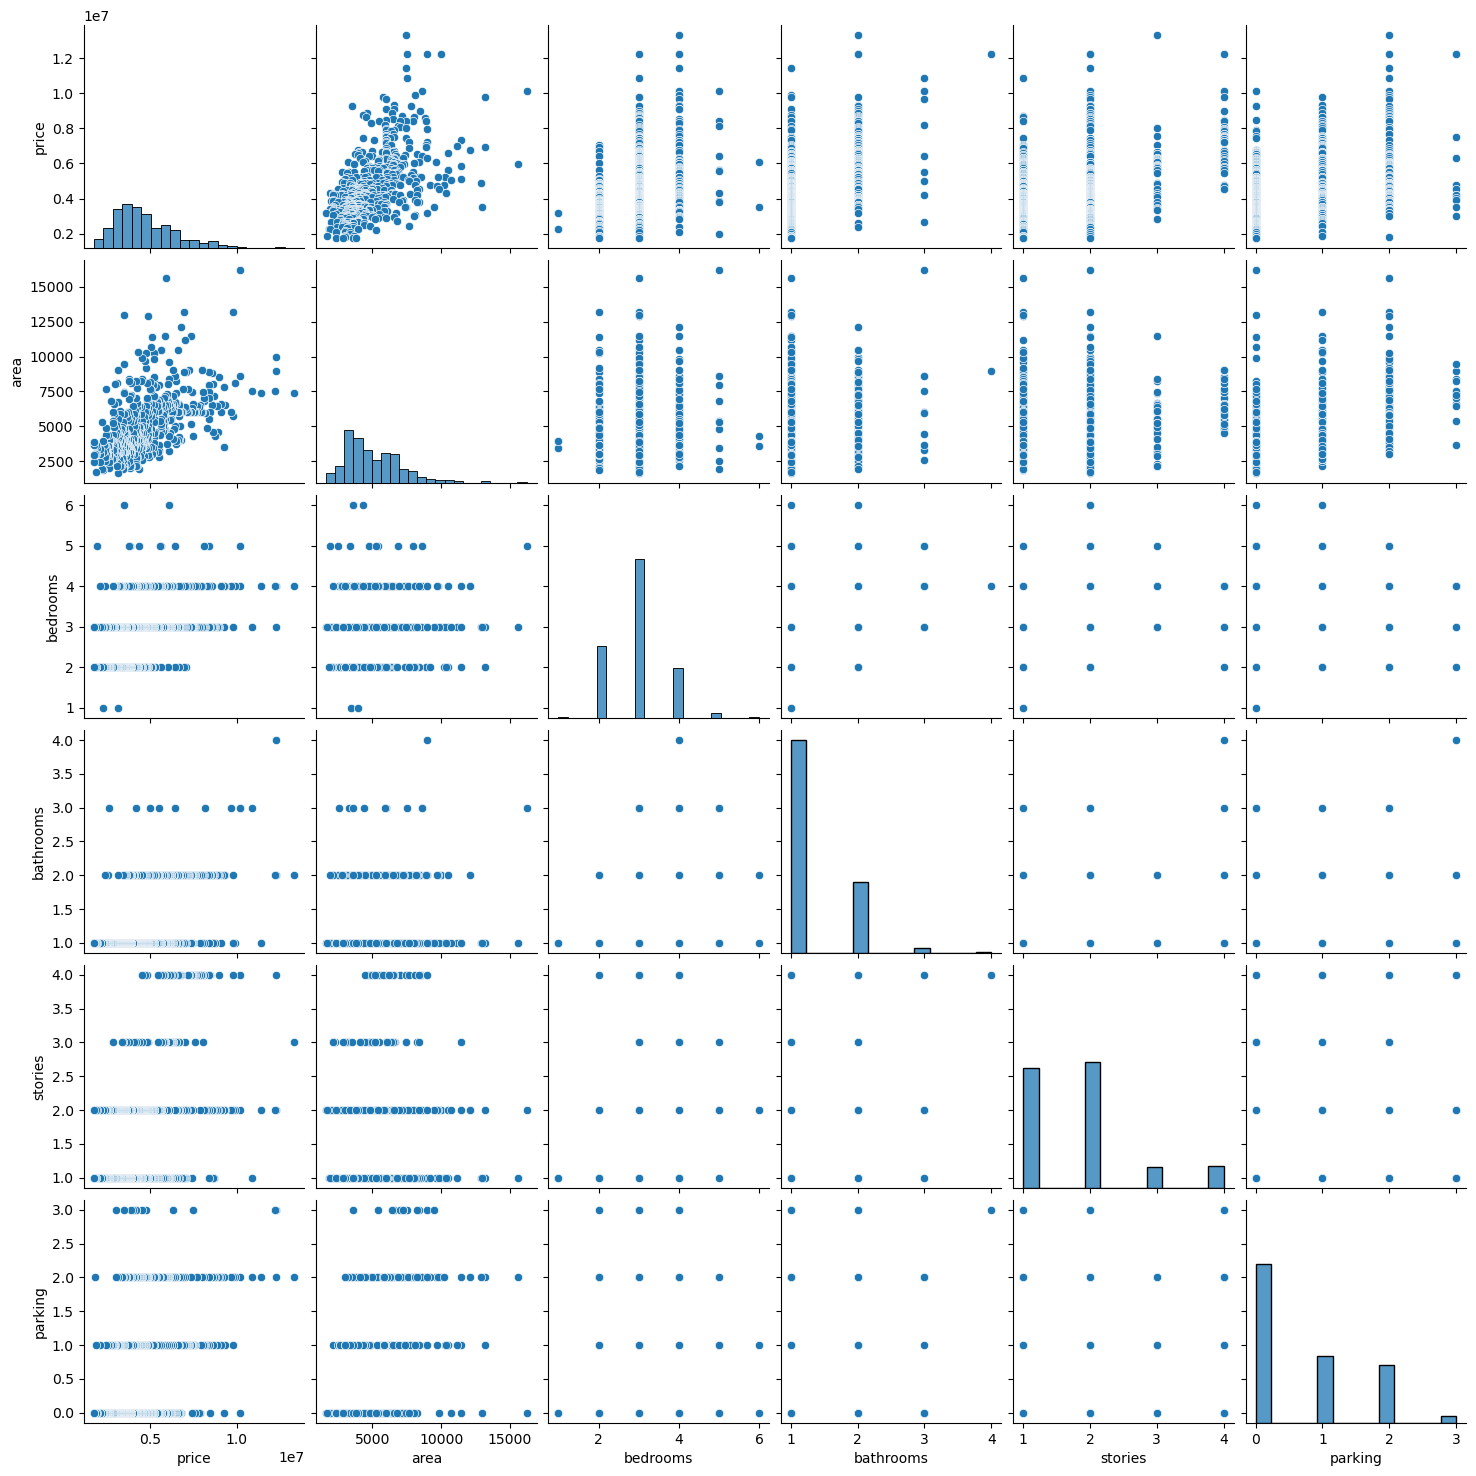

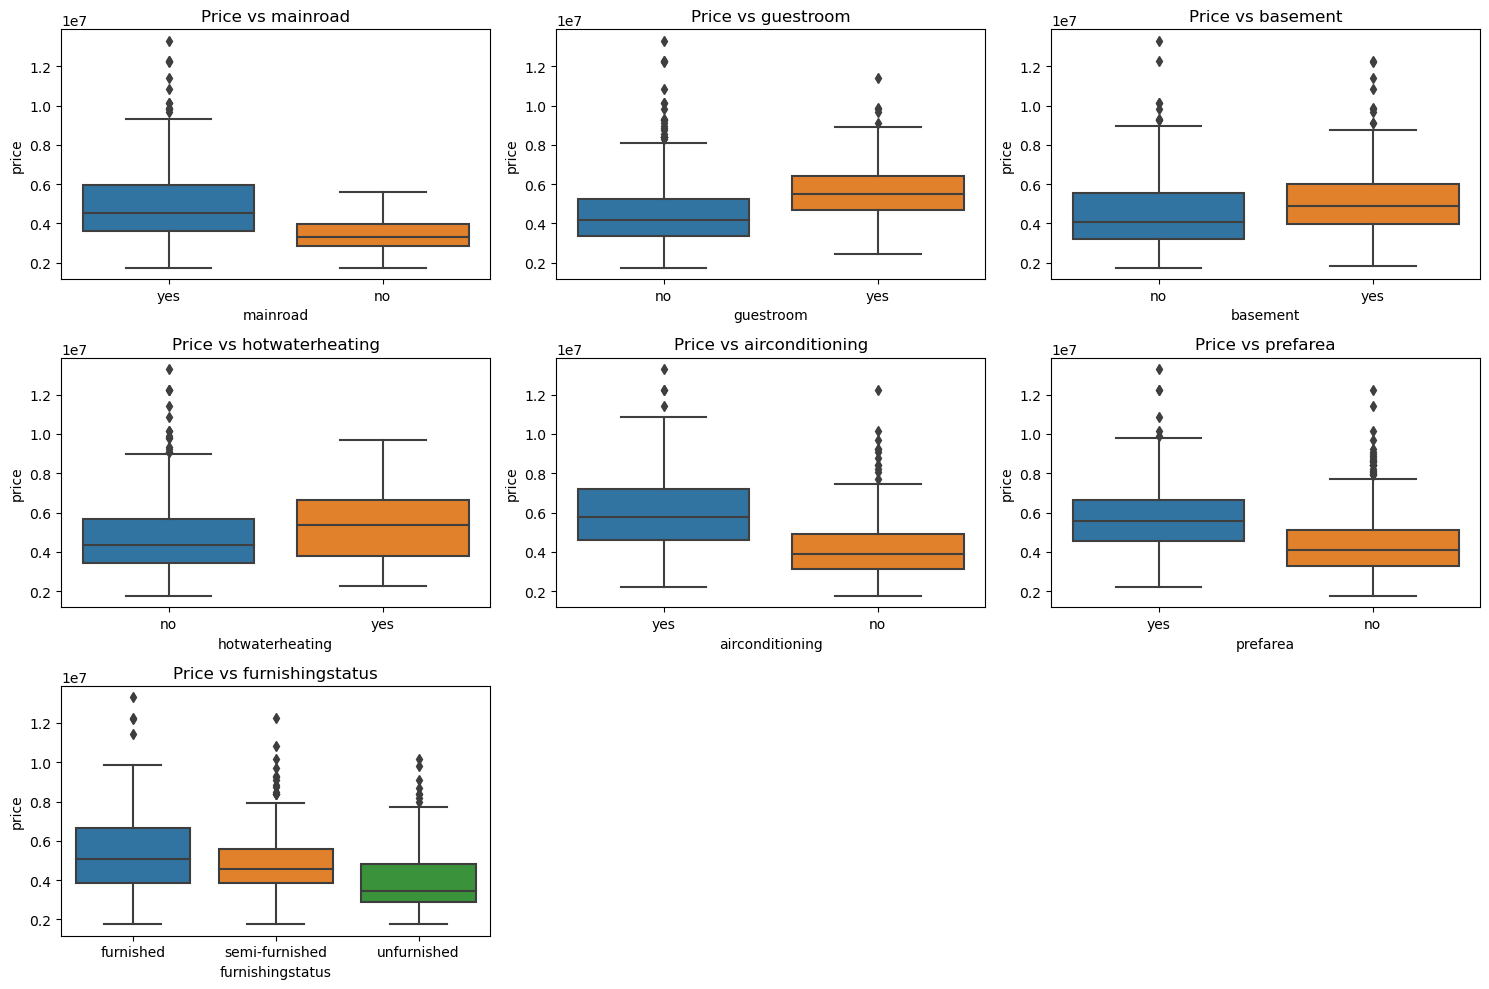

In [3]:
# Step 3: Data Visualization

# Pairplot for numerical variables
sns.pairplot(df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']])
plt.show()

# Boxplot for categorical variables vs. price
categorical_vars = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
plt.figure(figsize=(15, 10))
for i, var in enumerate(categorical_vars, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=var, y='price', data=df)
    plt.title(f'Price vs {var}')
plt.tight_layout()
plt.show()

#### Interpretation:


- **Numerical Features:** area and bathrooms strongly correlate with higher prices, while bedrooms, stories, and parking show weaker positive trends.
- **Categorical Features:** airconditioning, prefarea, and furnishingstatus (especially furnished) significantly increase house prices; mainroad and guestroom also contribute positively but less so.
- **Variability:** Both numerical and categorical features exhibit skewness and outliers, suggesting potential non-linear relationships or the need for robust modeling.
- **Key Drivers:** area, bathrooms, and airconditioning emerge as primary influencers of price based on visual patterns.

In [4]:
# Step 4: Data Preprocessing

# Convert binary categorical variables to 0/1
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Create dummy variables for furnishingstatus
furnishing_dummies = pd.get_dummies(df['furnishingstatus'], drop_first=True, dtype=int)
df = pd.concat([df, furnishing_dummies], axis=1)
df.drop('furnishingstatus', axis=1, inplace=True)

# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

# Scale numerical features
scaler = MinMaxScaler()
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Display the preprocessed training data
print("Preprocessed X_train Head:\n", X_train.head())

Preprocessed X_train Head:
          area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
359  0.155227       0.4        0.0  0.000000         1          0         0   
19   0.403379       0.4        0.5  0.333333         1          0         0   
159  0.115628       0.4        0.5  0.000000         1          1         1   
35   0.454417       0.4        0.5  1.000000         1          0         0   
28   0.538015       0.8        0.5  0.333333         1          0         1   

     hotwaterheating  airconditioning   parking  prefarea  semi-furnished  \
359                0                0  0.333333         0               0   
19                 0                1  0.333333         1               1   
159                0                1  0.000000         0               0   
35                 0                1  0.666667         0               0   
28                 1                0  0.666667         0               0   

     unfurnished  
359            

#### Explanation:

- Binary Encoding: Categorical variables with 'yes'/'no' values are mapped to 1/0 for numerical representation.
- Dummy Variables: furnishingstatus (furnished, semi-furnished, unfurnished) is converted to dummy variables, dropping the first category (furnished) to avoid multicollinearity.
- Feature-Target Split: price is the target variable (y), and all other columns are features (X).
- Train-Test Split: 70% training and 30% testing data, with a fixed random_state for reproducibility.
- Scaling: Numerical features are scaled to a 0-1 range using MinMaxScaler to ensure equal contribution to the model.

In [5]:
# Step 5: Build the Multiple Linear Regression Model

# Add a constant to the training data for statsmodels
X_train_sm = sm.add_constant(X_train)

# Fit the model
model = sm.OLS(y_train, X_train_sm).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     60.40
Date:                Wed, 09 Apr 2025   Prob (F-statistic):           8.83e-83
Time:                        22:45:33   Log-Likelihood:                -5814.1
No. Observations:                 381   AIC:                         1.166e+04
Df Residuals:                     367   BIC:                         1.171e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.981e+06   2.42e+05     

#### Explanation:

- sm.add_constant() adds an intercept term to the model (required for statsmodels).
- sm.OLS() fits a Multiple Linear Regression model using Ordinary Least Squares.
- model.summary() provides detailed statistics, including coefficients, p-values (to assess feature significance), and R-squared (model fit).


#### Insights

- R-squared (e.g., 0.681) indicates the model explains ~68% of the variance in house prices.
- P-values < 0.05 (e.g., for area, bedrooms) suggest these features are statistically significant.

Mean Squared Error (MSE): 1283969782447.75
Root Mean Squared Error (RMSE): 1133123.90
R-squared: 0.67


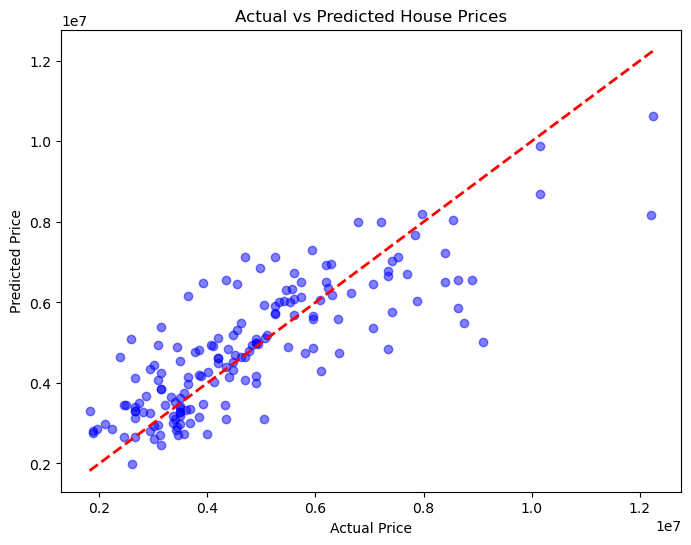

In [6]:
# Step 6: Model Evaluation

# Add constant to test data
X_test_sm = sm.add_constant(X_test)

# Make predictions
y_pred = model.predict(X_test_sm)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

#### Explanation:

- Predictions are made on the test set using the trained model.
- MSE measures average squared error, RMSE provides error in the same units as the target (price), and R-squared assesses model fit on the test set.
- The scatter plot visualizes how well predictions align with actual values (closer to the red line = better fit).

#### Interpretation

- RMSE of ~1.32 million indicates average prediction error in price units.
- R-squared of 0.65 suggests the model explains 65% of the variance in the test set, slightly lower than the training set (possible overfitting).

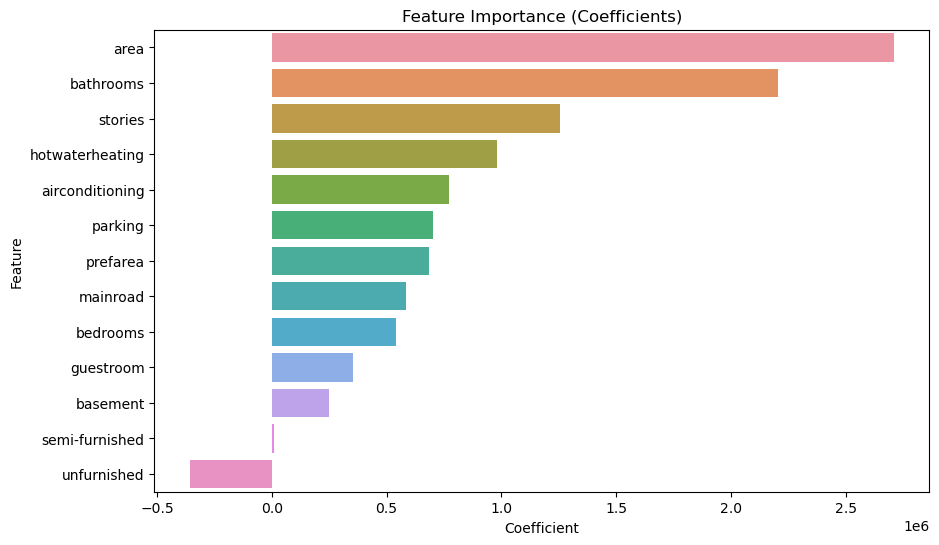

In [7]:
# Step 7: Feature Importance

# Extract coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.params[1:]  # Exclude intercept
})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title("Feature Importance (Coefficients)")
plt.show()

#### Interpretation

- **Top Influencers:** area (highest coefficient, ~ 2.5M) and bathrooms (~ 2.2M) are the strongest positive predictors of house price, indicating their significant impact.
- **Moderate Contributors:** Features like stories (~ 1.5M), hotwaterheating (~ 1.3M), and airconditioning (~1.2M) also positively influence price but to a lesser extent.
- **Negative Impact:** unfurnished (negative coefficient, ~ -0.5M) suggests that unfurnished houses tend to have lower prices compared to the baseline (furnished, dropped category).
- **Minor Effects:** Features like guestroom, basement, and semi-furnished have smaller coefficients (~0.5M–0.8M), indicating weaker influence on price.

In [8]:
# Step 8: Conclusion and Future Improvements

print("Conclusion:")
print("The Multiple Linear Regression model successfully predicts house prices with an R-squared of", round(r2, 2), "on the test set.")
print("Key features influencing price include area, bathrooms, and air conditioning.")
print("\nFuture Improvements:")
print("- Address potential multicollinearity using Variance Inflation Factor (VIF).")
print("- Experiment with feature selection or regularization (e.g., Ridge, Lasso).")
print("- Try non-linear models (e.g., Random Forest) for better performance.")

Conclusion:
The Multiple Linear Regression model successfully predicts house prices with an R-squared of 0.67 on the test set.
Key features influencing price include area, bathrooms, and air conditioning.

Future Improvements:
- Address potential multicollinearity using Variance Inflation Factor (VIF).
- Experiment with feature selection or regularization (e.g., Ridge, Lasso).
- Try non-linear models (e.g., Random Forest) for better performance.
